# Pre-lab 1 — Failure Modes, Calibration, and the Equation Design — SOLUTION KEY
### ME 323 Module 1 (staff only)

You will load the class beam data, compute strength-to-weight, code two
failure-mode formulas, check the predictions against what actually broke,
**calibrate three parameters of the physics to the data**, and optimize a
design. The optimized beam is the **class equation design** — staff print and
test one for the whole class, and its result feeds Pre-lab 2.

*(Lines marked `### FILL IN` are yours. Each step prints a checkpoint: if you
are not arriving at the stated value, check your work or talk to a TA.)*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
CS = 1.0                          # web shear-strength multiplier    (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
print("Constants loaded. Nominal SY =", SY/1e6, "MPa")

Constants loaded. Nominal SY = 76.0 MPa


## 1. The data

Fourteen real three-point-bend results: beams printed at 172 mm, tested on a
150 mm span. `b` = web thickness, `H` = web height (mm); the flange thickness
follows as (18 − H)/2. `failure_note` is what the technician wrote down —
read them.

In [2]:
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_g"] = mass_g(df.b, df.H)
print(len(df), "tested beams")
df[["beam_id", "b", "H", "strength_N", "failure_note"]]

loaded from GitHub
14 tested beams


,beam_id,b,H,strength_N,failure_note
0,1,7.00,16.0,829.4,Complete vertical fracture across the center o...
1,2,7.00,10.5,948.8,Complete vertical fracture across the center o...
2,3,4.85,14.4,724.1,"Vertical fracture on the bottom of the beam, b..."
3,4,3.25,15.1,588.8,"Vertical fracture on the bottom of the beam, b..."
4,5,3.55,7.5,937.4,Complete vertical fracture across the center o...
5,6,4.60,13.1,759.0,Complete vertical fracture across the center o...
6,7,3.70,11.1,741.3,Complete vertical fracture across the center o...
7,8,6.40,10.3,882.5,Complete vertical fracture across the center o...
8,9,1.75,15.8,314.4,Twisted off the test stand and flipped over
9,10,5.95,6.3,918.4,Complete vertical fracture across the center o...


## 2. Strength-to-weight

Mass comes from the cross-section area times a calibrated constant:
$A = bH_{web} + B(TH - H_{web})$, mass $= K_{mass} A$. **FILL IN** str/w.

In [3]:
df["str_to_weight"] = df.strength_N / df.mass_g
top = df.sort_values("str_to_weight", ascending=False)
print(top[["beam_id", "b", "H", "strength_N", "str_to_weight"]].head().round(2).to_string(index=False))
print("\nCHECKPOINT: the best tested beam should be beam 4 "
      "(b=3.25, H_web=15.1) at 36.9 N/g.")
print("If you are not getting that, check your work or talk to a TA.")

 beam_id    b    H  strength_N  str_to_weight
       4 3.25 15.1       588.8          36.88
      14 1.40 10.4       654.6          35.35
      11 4.00 13.5       706.8          34.91
       5 3.55  7.5       937.4          34.83
       6 4.60 13.1       759.0          33.97

CHECKPOINT: the best tested beam should be beam 4 (b=3.25, H_web=15.1) at 36.9 N/g.
If you are not getting that, check your work or talk to a TA.


## 3. Section geometry (provided)

All three failure formulas need section properties. Note the units: this
returns **meters**, while `b`, `H`, `L` arrive in **millimeters**.

In [4]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    beta = lambda t, a: 1 - 0.63*(t/a) + 0.052*(t/a)**5
    J  = (1/3)*beta(b_, h_)*h_*b_**3 + (2/3)*beta(tf_, B_)*B_*tf_**3
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_)
section_props(2.0, 12.0)

{'Ix': 3.708e-09,
 'Iy': 5.08e-10,
 'J': 1.7464295879176952e-10,
 'Cw': 2.8575e-14,
 'c': 0.009,
 'b': 0.002,
 'h': 0.012}

## 4. Failure mode: bending

Central load, three-point bending. The outer fiber yields when
$\sigma = Mc/I_x = \sigma_y$ with $M = PL/4$:

$$P_{bend} = \frac{4\,\sigma_y I_x}{c\,L}$$

`sy` is a *parameter* here (you calibrate it later), so pass it in. **FILL IN**.

In [5]:
def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)

Pb_check = P_bend(section_props(2.0, 12.0), SY)
assert 750 < Pb_check < 920, (
    f"P_bend(2,12) = {Pb_check:.6g} N is off. section_props returns meters and "
    "Pa; L arrives in mm.")
print(f"P_bend(2,12) = {Pb_check:.1f} N   (checkpoint: about 835 N)")

P_bend(2,12) = 835.0 N   (checkpoint: about 835 N)


## 5. Failure mode: shear (+ the interaction)

Average web shear at von Mises yield, with a strength multiplier `cs` you will
calibrate ($\tau_y = c_s\,\sigma_y/\sqrt3$, web area $bH_{web}$, $V = P/2$):

$$P_{shear} = 2\,(bH_{web})\,\frac{c_s\,\sigma_y}{\sqrt3}$$

Bending and shear act together:
$\; 1/P_{vm}^2 = 1/P_{bend}^2 + 1/P_{shear}^2$. **FILL IN** both.

In [6]:
def P_shear(p, sy, cs):
    return 2 * (cs*sy/np.sqrt(3)) * p["b"]*p["h"]
def P_vm(Pb, Ps):
    return 1.0/np.sqrt(1/Pb**2 + 1/Ps**2)

p = section_props(2.0, 12.0)
Ps_check = P_shear(p, SY, CS)
Pvm_check = P_vm(P_bend(p, SY), Ps_check)
assert 1900 < Ps_check < 2320, f"P_shear(2,12) = {Ps_check:.6g} N is off (expect ~2100 N)."
assert Pvm_check < min(P_bend(p, SY), Ps_check), \
    "P_vm must sit below both P_bend and P_shear."
print(f"P_shear = {Ps_check:.1f} N,  P_vm = {Pvm_check:.1f} N   (checkpoints: ~2106, ~776)")

P_shear = 2106.2 N,  P_vm = 776.2 N   (checkpoints: ~2106, ~776)


## 6. Lateral-torsional buckling (provided)

LTB carries the most assumptions, so it is given: warping, load applied at the
top flange, an effective-length factor `k` describing how the fixture braces
the beam, and a yield cap. `k` is a property of the **fixture**, not the beam
— and it is one of the three parameters you calibrate next.

In [7]:
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)

def capacity(b, H, sy, k, cs):
    """Predicted failure load: interaction AND the LTB cap."""
    p = section_props(b, H)
    return min(P_vm(P_bend(p, sy), P_shear(p, sy, cs)), P_LTB(p, sy, k))

def gov_mode(b, H, sy, k, cs):
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_shear(p, sy, cs), P_LTB(p, sy, k)
    # note the 0.999: where the yield cap is active P_LTB == P_bend exactly,
    # and a tie must not be called "LTB"
    return "shear" if Ps < min(Pb, Pl) else ("LTB" if Pl < 0.999*Pb else "bend")

print(f"capacity(2,16) = {capacity(2, 16, SY, K_LTB, CS):.0f} N, "
      f"mode = {gov_mode(2, 16, SY, K_LTB, CS)}")

capacity(2,16) = 390 N, mode = LTB


## 7. How good are the handbook numbers?

Predict every tested beam with the nominal values (σ_y = 76 MPa, k = 0.33,
c_s = 1) and plot predicted vs measured.

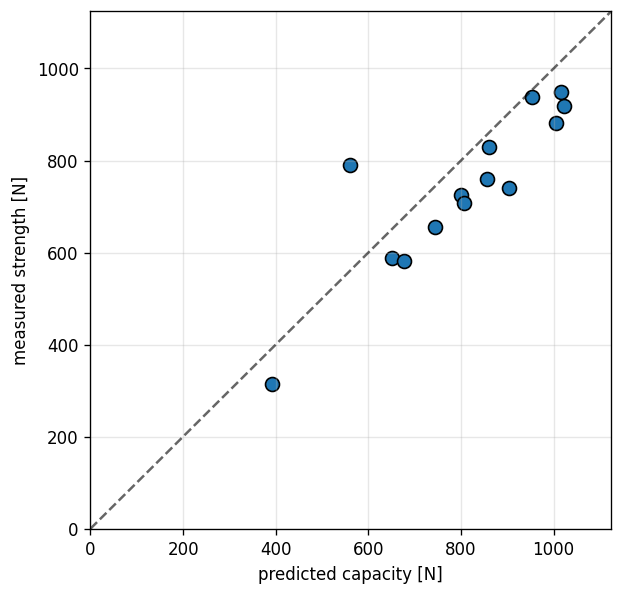

nominal-parameter error: 13.6% MAPE   (checkpoint: about 14%)
Look at WHERE the misses are before you fix them. Which beams, which notes?


In [8]:
df["cap_nominal"] = [capacity(b, H, SY, K_LTB, CS) for b, H in zip(df.b, df.H)]
mape_nom = (df.cap_nominal/df.strength_N - 1).abs().mean()*100

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(df.cap_nominal, df.strength_N, s=70, edgecolor="k")
hi = max(df.cap_nominal.max(), df.strength_N.max())*1.1
ax.plot([0, hi], [0, hi], "k--", alpha=0.6)
ax.set_xlabel("predicted capacity [N]"); ax.set_ylabel("measured strength [N]")
ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.grid(alpha=0.3); plt.show()
print(f"nominal-parameter error: {mape_nom:.1f}% MAPE   (checkpoint: about 14%)")
print("Look at WHERE the misses are before you fix them. Which beams, which notes?")

## 8. Calibrate the three parameters

The handbook values were measured on other machines, other plastic, other
fixtures. Your data can do better. Define the misfit as the **mean squared
log-error** (relative errors, so a 5% miss on a weak beam counts like a 5%
miss on a strong one):

$$\mathcal{L}(\sigma_y, k, c_s) = \frac{1}{14}\sum_i
\left[\ln P_{pred,i} - \ln P_{meas,i}\right]^2$$

**FILL IN** the loss. The optimizer (coarse grid, then a polish) is provided.

In [9]:
from scipy.optimize import minimize

def loss(theta):
    sy, k, cs = theta
    if not (30e6 < sy < 150e6 and 0.05 < k < 1.5 and 0.2 < cs < 4):
        return 1e9
    pred = np.array([capacity(b, H, sy, k, cs) for b, H in zip(df.b, df.H)])
    return float(np.mean((np.log(pred) - np.log(df.strength_N.values))**2))

grid = [(sy, k, cs) for sy in np.linspace(55e6, 100e6, 19)
        for k in np.linspace(0.10, 0.90, 17) for cs in (0.6, 0.8, 1.0, 1.3, 1.7)]
theta0 = min(grid, key=loss)
res = minimize(loss, theta0, method="Nelder-Mead",
               options=dict(xatol=1e-4, fatol=1e-10, maxiter=4000))
SY_CAL, K_CAL, CS_CAL = res.x
df["cap_cal"] = [capacity(b, H, SY_CAL, K_CAL, CS_CAL) for b, H in zip(df.b, df.H)]
mape_cal = (df.cap_cal/df.strength_N - 1).abs().mean()*100
print(f"calibrated: sigma_y = {SY_CAL/1e6:.1f} MPa, k = {K_CAL:.3f}, cs = {CS_CAL:.2f}")
print(f"calibrated error: {mape_cal:.1f}% MAPE (was {(df.cap_nominal/df.strength_N-1).abs().mean()*100:.1f}%)")
print("\nCHECKPOINT: you should arrive at sigma_y = 66.5 MPa, k = 0.377, "
      "cs = 2.25, error = 4.2% MAPE.")
print("If you are not getting that, check your loss function or talk to a TA.")

calibrated: sigma_y = 66.5 MPa, k = 0.377, cs = 2.25
calibrated error: 4.2% MAPE (was 13.6%)

CHECKPOINT: you should arrive at sigma_y = 66.5 MPa, k = 0.377, cs = 2.25, error = 4.2% MAPE.
If you are not getting that, check your loss function or talk to a TA.


**Read the numbers before moving on.** σ_y came out ~13% below the handbook —
printed plastic with layer lines is weaker than the datasheet coupon. k landed
near 0.38 — the fixture braces the beam better than a free span (k = 1) but
worse than fully clamped. And c_s ≈ 2.3 says the average-web-shear formula was
far too pessimistic — the beams that failed near the "shear" corner actually
peeled apart at the flange–web joint, a mode no yield formula contains. A
fitted parameter can be a *correction* or a *confession*; decide which each of
these is for your memo.

## 9. Optimize: the equation design

Search the design box for the best predicted strength-to-weight using your
**calibrated** parameters. **FILL IN** the objective line.

In [10]:
best = (None, None, -1)
for b in np.arange(1.25, 7.01, 0.05):
    for H in np.arange(5.0, 16.01, 0.05):
        cap = capacity(b, H, SY_CAL, K_CAL, CS_CAL)
        sw = cap / mass_g(b, H)
        if sw > best[2]:
            best = (round(b, 2), round(H, 2), sw)
b_eq, H_eq, sw_eq = best
print(f"EQUATION DESIGN:  b = {b_eq} mm,  H_web = {H_eq} mm  ->  "
      f"predicted str/w = {sw_eq:.1f} N/g  ({gov_mode(b_eq, H_eq, SY_CAL, K_CAL, CS_CAL)}-governed)")
print("\nCHECKPOINT: you should arrive at b = 1.25, H_web = 13.40, predicted 46.6 N/g.")
print("If you are not getting that, check your work or talk to a TA.")

EQUATION DESIGN:  b = 1.25 mm,  H_web = 13.4 mm  ->  predicted str/w = 46.6 N/g  (LTB-governed)

CHECKPOINT: you should arrive at b = 1.25, H_web = 13.40, predicted 46.6 N/g.
If you are not getting that, check your work or talk to a TA.


Staff print and test **one** class equation beam — everyone's answer is the
same beam, that is the point of a deterministic recipe. The measured result is
revealed at the start of Pre-lab 2.

## Memo questions

1. Which failure mode governs the equation design under the calibrated
   parameters? Under the nominal ones? If they differ, what changed and why?
2. The calibration moved σ_y, k, and c_s. For each: correction or confession?
   (Is the parameter fixing a wrong *number*, or absorbing a wrong *model*?)
3. Your design sits on the edge of the design box, where the predicted str/w
   is still climbing as b shrinks. What should that make you suspect, given
   which beams the notes say peeled apart?